<a href="https://colab.research.google.com/github/prakalya427-pixel/-AI-Internship-/blob/main/Mnist_Dataset_using_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import  tensorflow as tf
from tensorflow.keras.layers import  Input,LSTM,Dense
from tensorflow.keras.layers import Layer
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import  Model

In [15]:
(x_train,y_train),(x_label,y_label)=mnist.load_data()
x_train,x_label=x_train/255.0,x_label/255

In [30]:
model=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(30,)),
     tf.keras.layers.Dense(20,activation='relu'),
      tf.keras.layers.Dense(2,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
input_shape=(28,28)
inputs=Input(shape=input_shape)
rnn=LSTM(128)(inputs)
outputs=Dense(10,activation='softmax')(rnn)
model=Model(inputs=inputs,outputs=outputs)

In [19]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [21]:
model.fit(x_train,y_train,validation_split=0.1,epochs=7)

Epoch 1/7
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 65s 38ms/step - accuracy: 0.8789 - loss: 0.3741 - val_accuracy: 0.9675 - val_loss: 0.1157
Epoch 2/7
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 61s 36ms/step - accuracy: 0.9662 - loss: 0.1125 - val_accuracy: 0.9732 - val_loss: 0.0920
Epoch 3/7
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 83s 37ms/step - accuracy: 0.9767 - loss: 0.0762 - val_accuracy: 0.9817 - val_loss: 0.0603
Epoch 4/7
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 37ms/step - accuracy: 0.9824 - loss: 0.0572 - val_accuracy: 0.9852 - val_loss: 0.0524
Epoch 5/7
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 37ms/step - accuracy: 0.9847 - loss: 0.0486 - val_accuracy: 0.9880 - val_loss: 0.0440
Epoch 6/7
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - accuracy: 0.9883 - loss: 0.0385 - val_accuracy: 0.9885 - val_loss: 0.0428
Epoch 7/7
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 37ms/step - accuracy: 0.9894 - loss: 0.0333 - val_accuracy: 0.9887 - val_loss: 0.0421


In [25]:
y_pred=model.predict(x_label)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


In [26]:
y_pred[4576]

array([1.5125027e-05, 3.2739270e-05, 1.9796220e-05, 1.7732166e-06,
       9.9918538e-01, 2.6712387e-06, 2.2288332e-05, 3.1361089e-04,
       1.9930356e-05, 3.8669369e-04], dtype=float32)

In [27]:
import numpy as np
y_pr=np.argmax(y_pred,axis=1)
print(y_pr[4576])

4


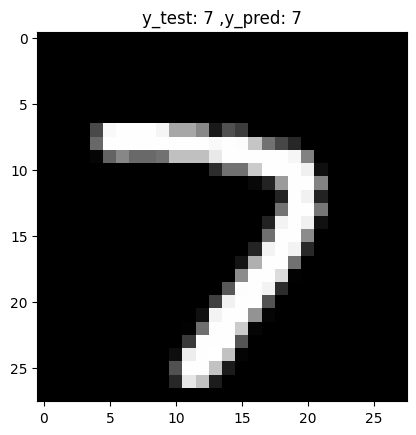

In [29]:
import matplotlib.pyplot as plt
plt.imshow(x_test[17],cmap='gray')
true_label = y_test[1703]
predicted_label = np.argmax(y_pred[17])
plt.title(f"y_test: {true_label} ,y_pred: {predicted_label}")
plt.show()